# Predicting Student Academic Math Performance

##### Original Dataset and Research: UC Irvine Student Performance, Cortez and Silva (2008) https://archive.ics.uci.edu/dataset/320/student%2Bperformance

### Data Upload

## Business Problem, Objectives, and Research Questions

**Business problem.** Failing a course is one of the earliest observable warning signs of dropout risk, but by the time a school sees a final grade, the term is already over and the window for intervention has closed. Schools have demographic, family, and lifestyle information about students from day one (parental background, study habits, social habits, past academic history) but no established, validated way to translate that information into an early signal of who is likely to struggle.

**Objective.** Determine whether demographic, family, and lifestyle factors, available before any grades exist for the current term, can accurately predict whether a student will pass or fail their final math grade, and identify which specific factors contribute most to failure risk.

**Decision this analysis supports.** If a reliable early-warning signal exists, a school could proactively direct limited intervention resources (tutoring, counseling, parent outreach) toward the students most likely to need it, rather than waiting until mid- or end-of-term grades reveal the problem. This analysis is meant to tell the school whether that kind of early, data-driven triage is realistic with the information it already has on hand, and if not, what would need to change to make it realistic.

**Research questions.**
1. Using only information available at the start of the school year (i.e., excluding G1/G2), how accurately can we predict whether a student will pass or fail their final math grade, and which modeling technique performs best?
2. What specific factors contribute most to a student's risk of failing, and how might a school use those factors to design targeted intervention programs?

**Why this matters.** A model doesn't need to be perfect to be useful; even a moderately accurate, well-understood risk signal could help a school prioritize outreach. But it does need to be validated rather than assumed, since deploying a weak or misleading model could waste intervention resources on the wrong students, or worse, create a false sense of security about students the model misses. The results below test that assumption directly.

In [ ]:
import pandas as pd

df = pd.read_excel("student-mat_csv.xlsx")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Establish and Create Binary Variables

In [ ]:
# Binary variable creation for target variable (G3) for classification
# 10 is the threshold for passing grade in Math based on the original dataset
df["pass"] = (df["G3"] >= 10).astype(int)
df[["G1", "G2", "G3", "pass"]].head()

,G1,G2,G3,pass
0,5,6,6,0
1,5,5,6,0
2,7,8,10,1
3,15,14,15,1
4,6,10,10,1


In [ ]:
# Create binary variables for all of our categorical variables with two levels

binary_var = {
    "school":     {"GP": 0, "MS": 1},
    "sex":        {"F": 0, "M": 1},
    "address":    {"R": 0, "U": 1},
    "famsize":    {"LE3": 0, "GT3": 1},
    "Pstatus":    {"T": 0, "A": 1},
    "schoolsup":  {"no": 0, "yes": 1},
    "famsup":     {"no": 0, "yes": 1},
    "paid":       {"no": 0, "yes": 1},
    "activities": {"no": 0, "yes": 1},
    "nursery":    {"no": 0, "yes": 1},
    "higher":     {"no": 0, "yes": 1},
    "internet":   {"no": 0, "yes": 1},
    "romantic":   {"no": 0, "yes": 1},
}

for column, mapping in binary_var.items():
    df[column] = df[column].map(mapping)

# Exploratory Data analysis
In this section we explore the dataset to be able to understand its structure, identify data quality issues, and visualize patterns before building predictive models.

In [ ]:
# Check the dimensions of the dataset
print("Dataset Shape:", df.shape)

# Display data types
df.info()

Dataset Shape: (395, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    int64 
 1   sex         395 non-null    int64 
 2   age         395 non-null    int64 
 3   address     395 non-null    int64 
 4   famsize     395 non-null    int64 
 5   Pstatus     395 non-null    int64 
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    int64 
 16  famsup      395 non-null    int64 
 17  paid        395 non-null    int64 
 18  activities  395 non-null    int64 
 19  nursery     395 non-null 

The dataset contains 395 student observations and 33 variables and both numerical and categorical features related to demographics, family background, academic performance, and lifestyle.

In [ ]:
# Check for duplicate observations
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


No duplicate records were found in the dataset.

In [ ]:
# Summary statistics
df.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.116456,0.473418,16.696203,0.777215,0.711392,0.103797,2.749367,2.521519,1.448101,2.035443,...,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,0.321177,0.499926,1.276043,0.416643,0.453690,0.305384,1.094735,1.088201,0.697505,0.839240,...,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,16.000000,1.000000,0.000000,0.000000,2.000000,2.000000,1.000000,1.000000,...,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,0.000000,0.000000,17.000000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000,2.000000,...,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,0.000000,1.000000,18.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,2.000000,...,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,1.000000


This summary statistics provides an overview of the numerical variables which include things like mean, minimum, maximum, and standard deviation.

# Pass vs. Fail

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

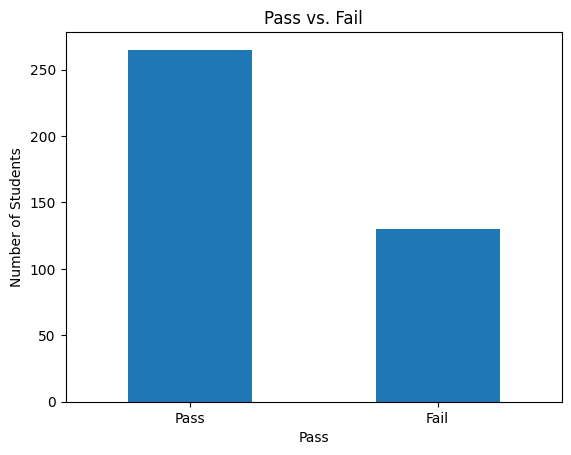

In [ ]:
df["pass"].value_counts().plot(kind="bar")

plt.title("Pass vs. Fail")
plt.xlabel("Pass")
plt.ylabel("Number of Students")
plt.xticks([0,1],["Pass","Fail"], rotation=0)

plt.show()

From the graph, we are able to see that most of the students passed the course, while a smaller number failed.

# Study Time

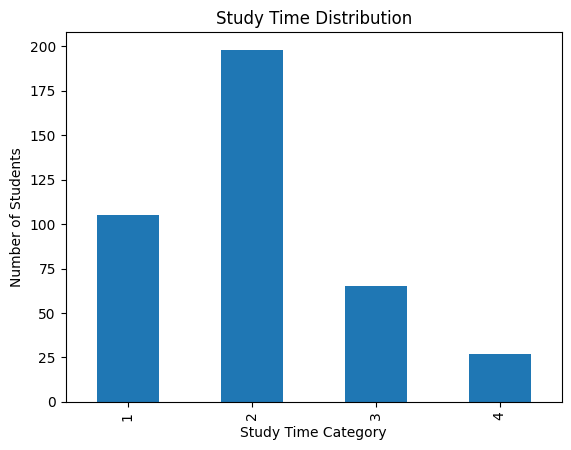

In [ ]:
df["studytime"].value_counts().sort_index().plot(kind="bar")

plt.title("Study Time Distribution")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

We are able to see that most of the students reported moderate study time, with less students studying at the highest level.

# Absences

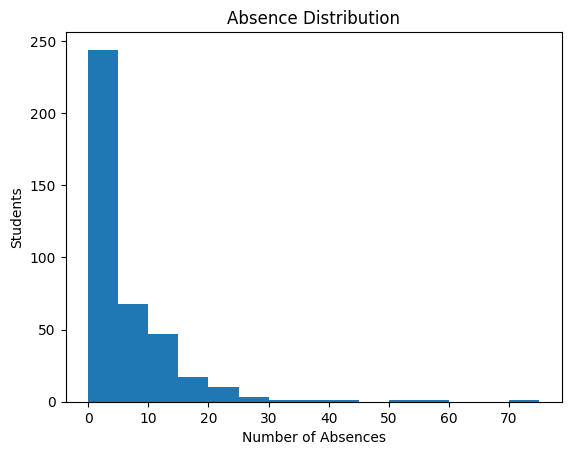

In [ ]:
plt.hist(df["absences"], bins=15)

plt.title("Absence Distribution")
plt.xlabel("Number of Absences")
plt.ylabel("Students")

plt.show()

Most of the students had very few absences, although a small number had significantly higher absence counts.

# Heatmap

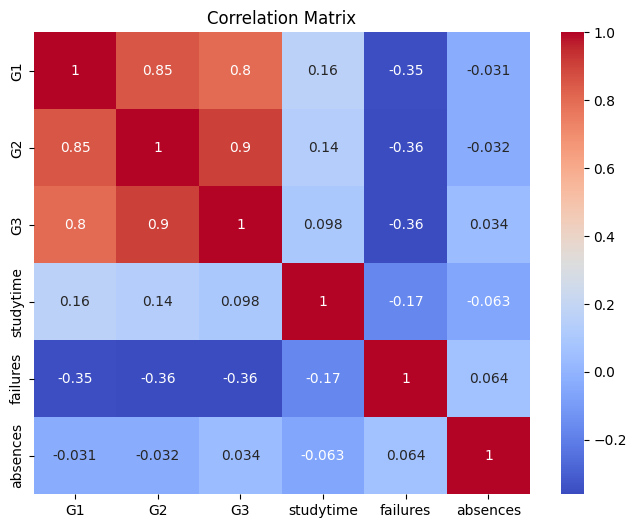

In [ ]:
corr = df[["G1","G2","G3","studytime","failures","absences"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

The heatmap helped us see which variables were most related to the students final grades. G1 and G2 had the strongest relationship with G3, while study time, failures, and absences also showed noticeable patterns.

**Methodology and Modeling**: We chose to incorporate past math grades (G1 and G2) in some models and exclude them in others. This allowed to view the variables distinctly to determine if previous academic performance mattered more than environmental and social factors

## Logistic Regression

In [ ]:
# One-hot encoding Mjob, Fjob, reason, and guardian because they have more than 2 categories

df = pd.get_dummies(df, columns=['Mjob', 'Fjob', 'reason', 'guardian'], drop_first=True)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,1,1,4,4,2,2,...,False,False,False,False,True,False,False,False,True,False
1,0,0,17,1,1,0,1,1,1,2,...,False,False,True,False,False,False,False,False,False,False
2,0,0,15,1,0,0,1,1,1,2,...,False,False,True,False,False,False,True,False,True,False
3,0,0,15,1,1,0,4,2,1,3,...,False,False,False,True,False,True,False,False,True,False
4,0,0,16,1,1,0,3,3,1,2,...,False,False,True,False,False,True,False,False,False,False


We will predict the passing grade as final grade greater than 10
We are excluding G1 and G2 since those are collected later and correlated with each other.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score, ConfusionMatrixDisplay)

In [ ]:
# Our predictors will be our X and y
# We are removing G1, G2, and G3 because G3 is our target and G1 and G2 we are not using
X = df.drop(columns=['G1', 'G2', 'G3', 'pass'])
y = df['pass']

In [ ]:
# Training and testing split at 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# logistic regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Run cross-validation for training data
cv_scores = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
print('Cross-validation accuracy:', cv_scores.round(3))
print(f'Mean Cross Validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')

Cross-validation accuracy: [0.703 0.635 0.683 0.698 0.73 ]
Mean Cross Validation accuracy: 0.690 (+/- 0.031)


In [ ]:
y_pred = logreg.predict(X_test)
# This will predict our probability of passing grades
y_prob = logreg.predict_proba(X_test)[:, 1]

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.3f}\n")

Test set accuracy: 0.658



In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

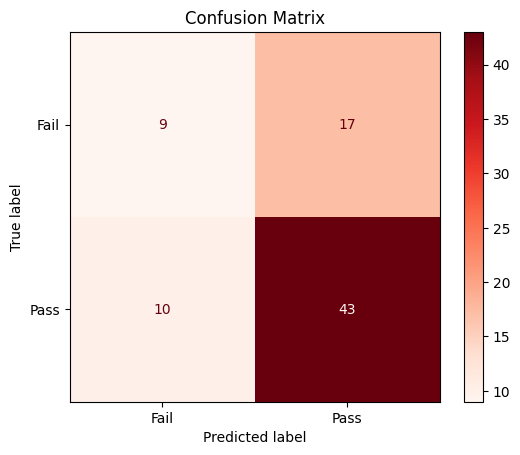

In [ ]:
cmgraph = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
cmgraph.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

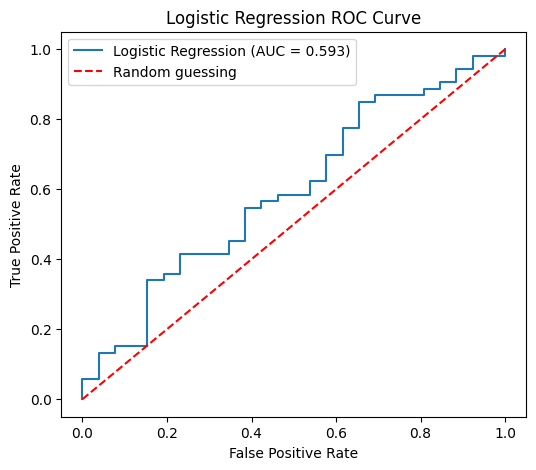

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle="--", color='red', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()

In [ ]:
# Check value of coefficents
coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_table

,feature,coefficient
16,higher,0.721561
26,Mjob_health,0.626439
5,Pstatus,0.511112
28,Mjob_services,0.494524
33,Fjob_teacher,0.399470
1,sex,0.394762
23,Walc,0.379624
36,reason_reputation,0.240287
31,Fjob_other,0.239047
0,school,0.218848


### Classification Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [ ]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)
print("Classification Tree Accuracy:", round(tree_accuracy, 3))

Classification Tree Accuracy: 0.62


In [ ]:
#Check training accuracy
train_pred = tree_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print("Training Accuracy:", round(train_accuracy, 3))
print("Testing Accuracy:", round(tree_accuracy, 3))

Training Accuracy: 1.0
Testing Accuracy: 0.62


In [ ]:
#Test different tree depths
depth_results = []
for depth in range(1, 11):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='accuracy')
    depth_results.append(scores.mean())
for depth, score in enumerate(depth_results, start=1):
    print(f"Depth {depth}: {score:.3f}")

Depth 1: 0.722
Depth 2: 0.699
Depth 3: 0.706
Depth 4: 0.696
Depth 5: 0.687
Depth 6: 0.706
Depth 7: 0.687
Depth 8: 0.661
Depth 9: 0.652
Depth 10: 0.623


In [ ]:
#Build tuned classification tree using best depth
tuned_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
tuned_tree.fit(X_train, y_train)
tuned_tree_pred = tuned_tree.predict(X_test)
tuned_tree_accuracy = accuracy_score(y_test, tuned_tree_pred)
print("Tuned Tree Accuracy:", round(tuned_tree_accuracy, 3))

Tuned Tree Accuracy: 0.671


In [ ]:
#Evaluate tuned classification tree
print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_tree_pred))
print("Classification Report:")
print(classification_report(y_test, tuned_tree_pred))

Confusion Matrix:
[[ 9 17]
 [ 9 44]]
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.35      0.41        26
           1       0.72      0.83      0.77        53

    accuracy                           0.67        79
   macro avg       0.61      0.59      0.59        79
weighted avg       0.65      0.67      0.65        79



In [ ]:
tree_prob = tuned_tree.predict_proba(X_test)[:, 1]
#ROC curve and AUC
tree_fpr, tree_tpr, tree_thresholds = roc_curve(y_test, tree_prob)
tree_auc = roc_auc_score(y_test, tree_prob)
print("Classification Tree AUC:", round(tree_auc, 3))

Classification Tree AUC: 0.588


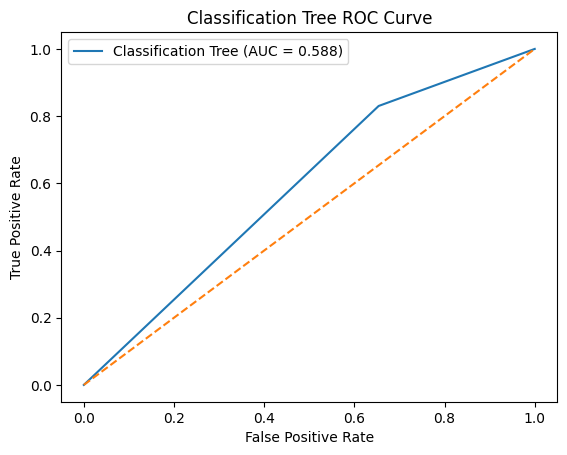

In [ ]:
#Plot ROC curve
plt.plot(tree_fpr, tree_tpr, label=f"Classification Tree (AUC = {tree_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classification Tree ROC Curve")
plt.legend()
plt.show()

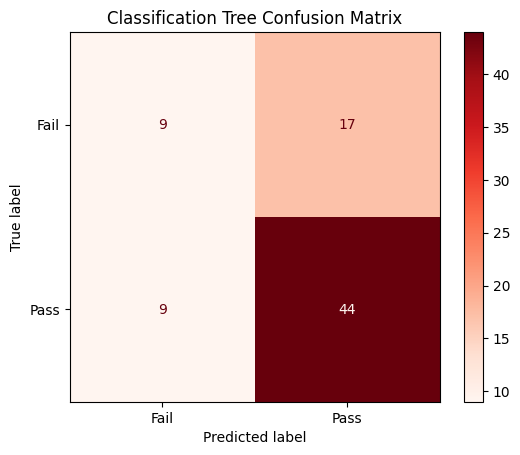

In [ ]:
#Plot confusion matrix
tree_cm = confusion_matrix(y_test, tuned_tree_pred)
tree_cmgraph = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=['Fail', 'Pass'])
tree_cmgraph.plot(cmap='Reds')
plt.title('Classification Tree Confusion Matrix')
plt.show()

In [ ]:
#Check feature importance
tree_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tuned_tree.feature_importances_}).sort_values('importance', ascending=False)
tree_importance

,feature,importance
10,failures,1.0
1,sex,0.0
0,school,0.0
3,address,0.0
4,famsize,0.0
5,Pstatus,0.0
2,age,0.0
6,Medu,0.0
7,Fedu,0.0
8,traveltime,0.0


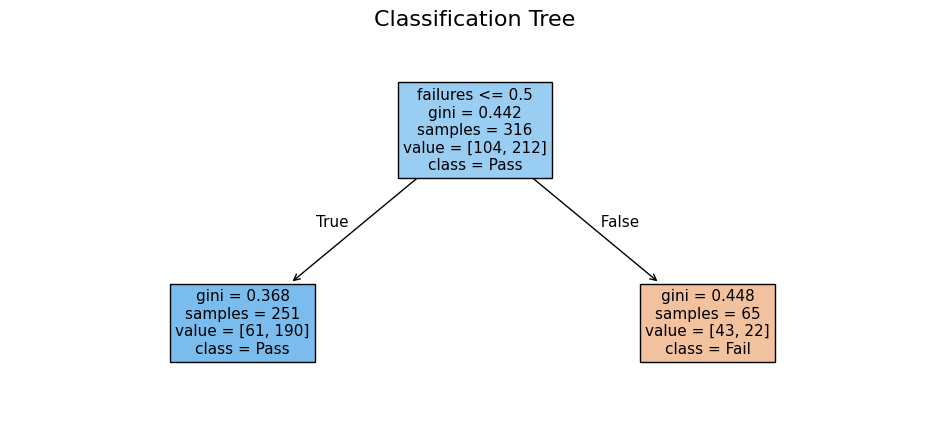

In [ ]:
#Plot classification tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 5))
plot_tree(
    tuned_tree,
    feature_names=X.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    fontsize=11)
plt.title('Classification Tree', fontsize=16)
plt.show()

### Classification Tree Findings
The unrestricted classification tree showed overfitting with 100% training accuracy and 62% testing accuracy. We used 5-fold cross-validation to compare tree depths from 1 to 10, and a maximum depth of 1 produced the highest average cross-validation accuracy of 72.2%. The tuned tree achieved 67.1% test accuracy and an AUC of 0.588. The number of past class failures was the most important predictor in the tuned classification tree. Students with no previous failures were predicted to pass, while students with one or more previous failures were predicted to fail.

### K-Means Clustering

For our clustering analysis, we used K-Means to see if students could be grouped based on having similar academic and behavioral characteristics. Unlike the classification models, clustering does not use the pass/fail outcome to create the groups.

In [ ]:
# Variables for K-Means clustering
cluster_features = [
    "studytime",
    "failures",
    "absences",
    "goout",
    "Dalc",
    "Walc"
]

X_cluster = df[cluster_features]

# Preview the selected variables
X_cluster.head()

,studytime,failures,absences,goout,Dalc,Walc
0,2,0,6,4,1,1
1,2,0,4,3,1,1
2,2,3,10,2,2,3
3,3,0,2,2,1,1
4,2,0,4,2,1,2


In [ ]:
# Standardize variables before K-Means clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

# Preview standardized data
X_scaled[:5]

array([[-0.04228585, -0.44994364,  0.03642446,  0.8014793 , -0.54069866,
        -1.00378921],
       [-0.04228585, -0.44994364, -0.21379577, -0.09790798, -0.54069866,
        -1.00378921],
       [-0.04228585,  3.58932316,  0.53686493, -0.99729526,  0.58338539,
         0.55109996],
       [ 1.15077909, -0.44994364, -0.464016  , -0.99729526, -0.54069866,
        -1.00378921],
       [-0.04228585, -0.44994364, -0.21379577, -0.99729526, -0.54069866,
        -0.22634463]])

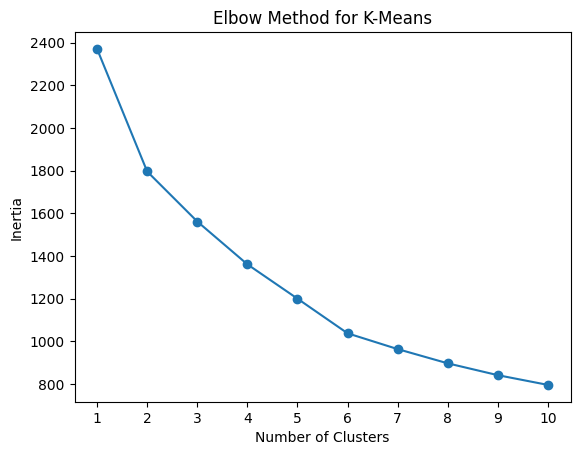

In [ ]:
# Use the Elbow Method to find the best # of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Create Elbow Method chart
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.show()

In [ ]:
# Build K-Means model using 2 clusters
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Assign each student to a cluster
df["cluster"] = kmeans.fit_predict(X_scaled)

# See how many students are in each cluster
df["cluster"].value_counts().sort_index()

,count
cluster,
0,283
1,112


In [ ]:
# Compare the characteristics of each cluster
cluster_summary = df.groupby("cluster")[
    ["studytime", "failures", "absences", "goout", "Dalc", "Walc"]
].mean()

cluster_summary.round(2)

,studytime,failures,absences,goout,Dalc,Walc
cluster,,,,,,
0,2.19,0.23,4.83,2.77,1.11,1.66
1,1.65,0.60,7.93,3.96,2.43,3.88


In [ ]:
# Compare performance between clusters
cluster_performance = df.groupby("cluster").agg(
    students=("cluster", "size"),
    average_G3=("G3", "mean"),
    pass_rate=("pass", "mean")
)

# Convert pass rate to percentage
cluster_performance["pass_rate"] = cluster_performance["pass_rate"] * 100

cluster_performance.round(2)

,students,average_G3,pass_rate
cluster,,,
0,283,10.67,70.67
1,112,9.77,58.04


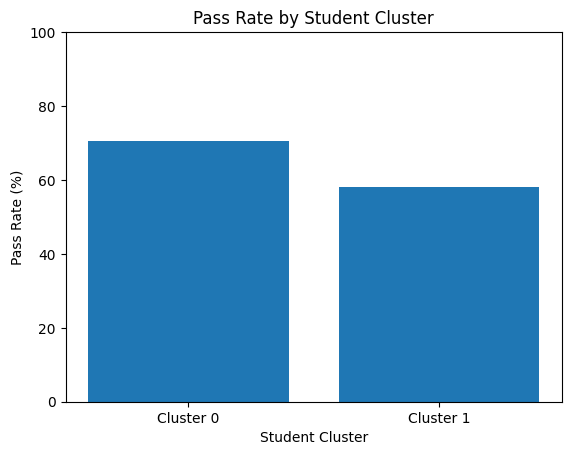

In [ ]:
# Compare pass rates between the two clusters
pass_rates = df.groupby("cluster")["pass"].mean() * 100

plt.bar(["Cluster 0", "Cluster 1"], pass_rates)

plt.title("Pass Rate by Student Cluster")
plt.xlabel("Student Cluster")
plt.ylabel("Pass Rate (%)")
plt.ylim(0, 100)

plt.show()

Cluster 0 had a higher pass rate than Cluster 1. Cluster 0 students also studied more and had fewer failures and absences, while Cluster 1 students had more absences, failures, and higher social activity.

In [ ]:
# Evaluate the K-Means clustering model
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, df["cluster"])

print("Silhouette Score:", round(sil_score, 3))

Silhouette Score: 0.299


### K-Mean Findings

The K-Means model separated the students into two groups based on their academic and behavioral characteristics. Cluster 0 had 283 students and had a higher pass rate of 70.67%, while Cluster 1 had 112 students with a pass rate of 58.04%. Cluster 0 studied more and had fewer absences and previous failures, while Cluster 1 had more absences, failures, and higher social activity. The silhouette score was 0.299, which shows that the clusters had some separation and some overlap. Overall, the clustering helped identify different student profiles that were associated with different academic outcomes.

### K-Nearest Neighbors
KNN was used to predict whether a student would pass or fail based on demographic, social, and school-related characteristics. Because KNN is distance-based, predictors were converted to numeric values and standardized before modeling. The preprocessing is repeated because the model requires its own numeric representation of the categorical predictors, including retaining all dummy categories. The KNN dataset was prepared separately from the datasets used for the other models.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
knn_df = pd.read_excel("student-mat_csv.xlsx")

knn_df["pass"] = (knn_df["G3"] >= 10).astype(int)

binary_var = {
    "school":     {"GP": 0, "MS": 1},
    "sex":        {"F": 0, "M": 1},
    "address":    {"R": 0, "U": 1},
    "famsize":    {"LE3": 0, "GT3": 1},
    "Pstatus":    {"T": 0, "A": 1},
    "schoolsup":  {"no": 0, "yes": 1},
    "famsup":     {"no": 0, "yes": 1},
    "paid":       {"no": 0, "yes": 1},
    "activities": {"no": 0, "yes": 1},
    "nursery":    {"no": 0, "yes": 1},
    "higher":     {"no": 0, "yes": 1},
    "internet":   {"no": 0, "yes": 1},
    "romantic":   {"no": 0, "yes": 1},
}

for column, mapping in binary_var.items():
    knn_df[column] = knn_df[column].map(mapping)

# Encoding categorical variables with more than two categories
knn_df = pd.get_dummies(knn_df, columns=["Mjob", "Fjob", "reason", "guardian"], drop_first=False, dtype=int)

# Predictor variables
X_knn = knn_df.drop(columns=["G1", "G2", "G3", "pass"])
y_knn = knn_df["pass"]

# Test / Train Split: 80/20
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.20, random_state=42, stratify=y_knn)

print(f"Training observations: {len(X_train_knn)}\nTesting observations: {len(X_test_knn)}")

# Scale features
scaler = StandardScaler()

# Fitting scaler using training data
X_train_knn_scaled = scaler.fit_transform(X_train_knn)

# Transforming test data
X_test_knn_scaled = scaler.transform(X_test_knn)

Training observations: 316
Testing observations: 79


In [ ]:
import numpy as np

# Trying k values with cross-validation
k_values = range(1, 21)
cv_scores = []
train_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn_scaled, y_train_knn, cv=5
    , scoring='accuracy')
    cv_scores.append(scores.mean())

    train_fold_scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_index, val_index in skf.split(X_train_knn_scaled, y_train_knn):
        X_train_fold, X_val_fold = X_train_knn_scaled[train_index], X_train_knn_scaled[val_index]
        y_train_fold, y_val_fold = y_train_knn.iloc[train_index], y_train_knn.iloc[val_index]
        knn.fit(X_train_fold, y_train_fold)
        train_fold_scores.append(knn.score(X_train_fold, y_train_fold))

    train_scores.append(np.mean(train_fold_scores))

best_k = k_values[np.argmax(cv_scores)]

for k, score in zip(k_values, cv_scores):
  print(f"k={k}, cv_score={score: .3f}")

print("")

print (f"Best k: {best_k}\nCross-Validation Accuracy: {max(cv_scores): .3f}\nCross-Validation Error: {1 - max(cv_scores): .3f}")

k=1, cv_score= 0.598
k=2, cv_score= 0.560
k=3, cv_score= 0.643
k=4, cv_score= 0.605
k=5, cv_score= 0.630
k=6, cv_score= 0.630
k=7, cv_score= 0.671
k=8, cv_score= 0.652
k=9, cv_score= 0.668
k=10, cv_score= 0.659
k=11, cv_score= 0.671
k=12, cv_score= 0.668
k=13, cv_score= 0.681
k=14, cv_score= 0.677
k=15, cv_score= 0.687
k=16, cv_score= 0.684
k=17, cv_score= 0.677
k=18, cv_score= 0.671
k=19, cv_score= 0.674
k=20, cv_score= 0.687

Best k: 15
Cross-Validation Accuracy:  0.687
Cross-Validation Error:  0.313


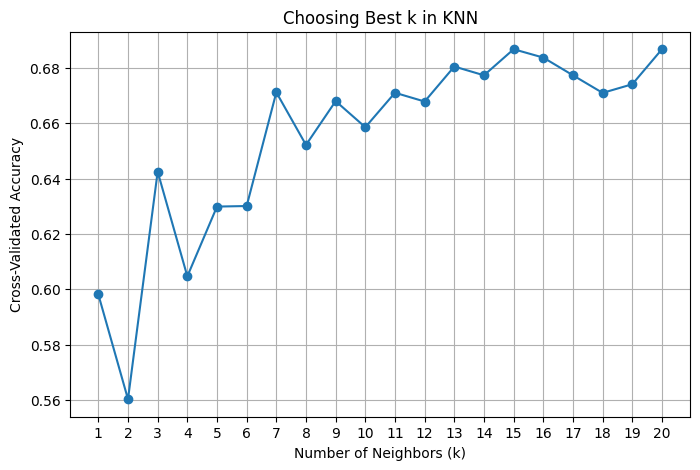

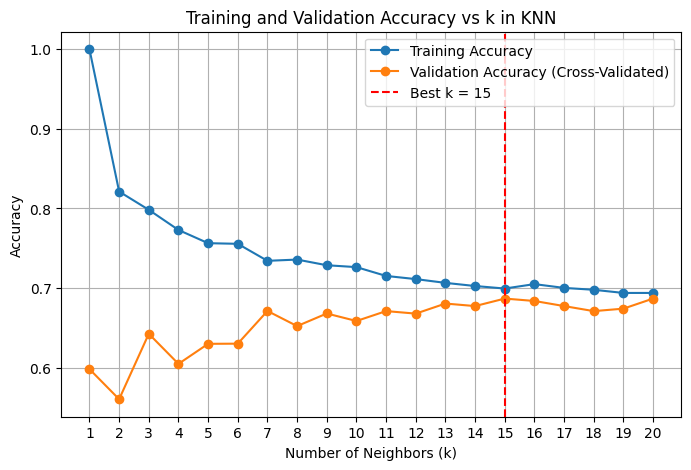

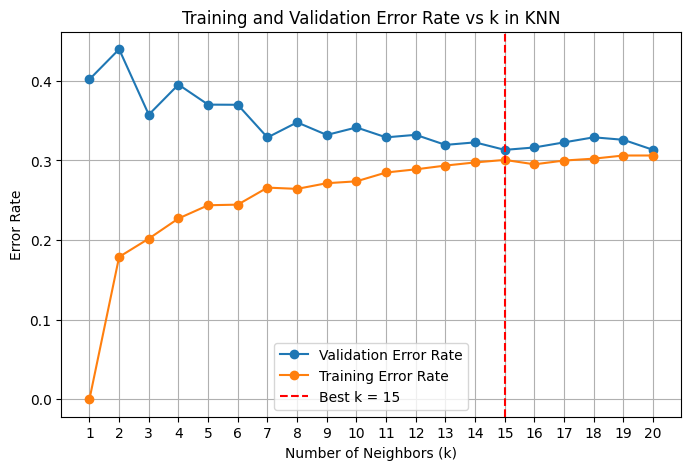

In [ ]:
# Plotting accuracy vs k-values
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Choosing Best k in KNN")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Plotting training and validatinon accuracy vs k values
plt.figure(figsize=(8,5))
plt.plot(k_values, train_scores, marker='o', label='Training Accuracy')
plt.plot(k_values, cv_scores, marker='o', label='Validation Accuracy (Cross-Validated)')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy vs k in KNN")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k = {best_k}')
plt.legend()
plt.show()

# Plotting error rate vs k-values
plt.figure(figsize=(8,5))
plt.plot(k_values, [1 - score for score in cv_scores], marker='o', label='Validation Error Rate')
plt.plot(k_values, [1 - score for score in train_scores], marker='o', label='Training Error Rate')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Error Rate")
plt.title("Training and Validation Error Rate vs k in KNN")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k = {best_k}')
plt.legend()
plt.show()

Training Confusion Matrix: 
[[ 17  87]
 [  5 207]]
Classification Report (Training):
               precision    recall  f1-score   support

        Fail       0.77      0.16      0.27       104
        Pass       0.70      0.98      0.82       212

    accuracy                           0.71       316
   macro avg       0.74      0.57      0.54       316
weighted avg       0.73      0.71      0.64       316

Test Confusion Matrix: 
[[ 2 24]
 [ 1 52]]
Classification Report (Test):
               precision    recall  f1-score   support

        Fail       0.67      0.08      0.14        26
        Pass       0.68      0.98      0.81        53

    accuracy                           0.68        79
   macro avg       0.68      0.53      0.47        79
weighted avg       0.68      0.68      0.59        79

Training Accuracy:  0.709
Test Accuracy:  0.684


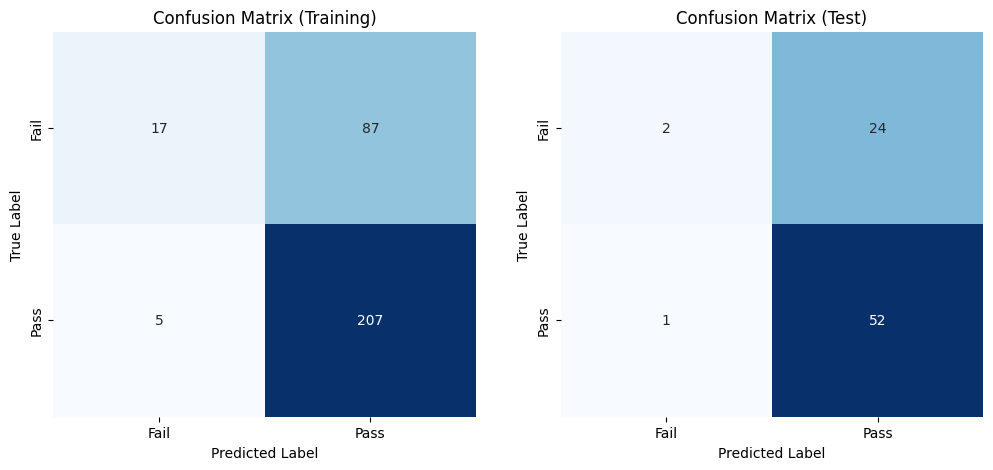

In [ ]:
# Fit model with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_knn_scaled, y_train_knn)

# Predicting training set
y_pred_knn_train = knn_best.predict(X_train_knn_scaled)

# Predicting test set
y_pred_knn_test = knn_best.predict(X_test_knn_scaled)

# Training Confusion Matrix and Classification Report
train_cm_knn = confusion_matrix(y_train_knn, y_pred_knn_train)
print(f'Training Confusion Matrix: \n{train_cm_knn}')
print('Classification Report (Training):\n', classification_report(y_train_knn, y_pred_knn_train, target_names=['Fail', 'Pass']))

# Test Confusion Matrix and Classification Report
test_cm_knn = confusion_matrix(y_test_knn, y_pred_knn_test)
print(f'Test Confusion Matrix: \n{test_cm_knn}')
print('Classification Report (Test):\n', classification_report(y_test_knn, y_pred_knn_test, target_names=['Fail', 'Pass']))

print(f'Training Accuracy: {knn_best.score(X_train_knn_scaled, y_train_knn): .3f}\nTest Accuracy: {knn_best.score(X_test_knn_scaled, y_test_knn): .3f}')

# Plotting the confusion matrices for test and training
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(train_cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix (Training)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.subplot(1, 2, 2)
sns.heatmap(test_cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix (Test)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

Test Accuracy:  0.684
Test Error Rate:  0.316
Test AUC:  0.458


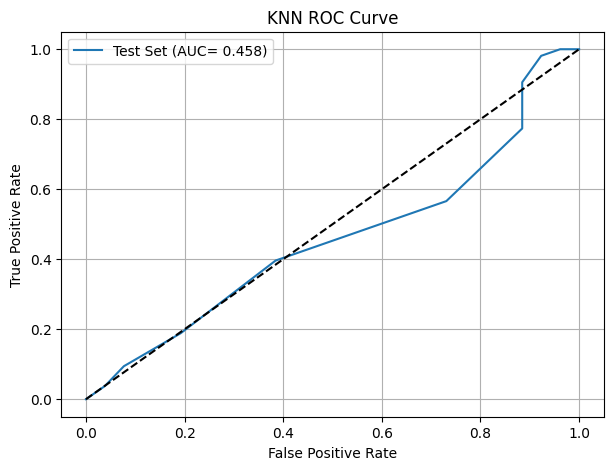

In [ ]:
# Calculate overall accuracy
knn_accuracy = accuracy_score(y_test_knn, y_pred_knn_test)

print(f"Test Accuracy: {knn_accuracy: .3f}")
print(f"Test Error Rate: {1 - knn_accuracy: .3f}")

# Calculating ROC Curve for best k
y_prob_test = knn_best.predict_proba(X_test_knn_scaled)[:,1]
fpr_test_knn, tpr_test_knn, thresholds_test_knn = roc_curve(y_test_knn, y_prob_test)
auc_test_knn = roc_auc_score(y_test_knn, y_prob_test)

print(f"Test AUC: {auc_test_knn: .3f}")

plt.figure(figsize=(7, 5))

plt.plot(fpr_test_knn, tpr_test_knn, label=f'Test Set (AUC={auc_test_knn: .3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.grid(True)
plt.legend()

plt.show()

### K-Nearest Neighbors Findings
The final model achieved 70.9% training accuracy and 68.4% test accuracy, suggesting little difference between training and test performance. However, KNN identified only 8% of students who failed, while correctly identifying 98% of students who passed. The test AUC of 0.458 also indicates weak ability to distinguish between passing and failing students. Overall, KNN was much more effective at predicting passes than identifying students at risk of failure.

## Model Comparison and Synthesis

Each model above was evaluated individually. Before drawing conclusions, we bring the results together side by side, since the pattern across models is more informative than any single result. Because our objective is early identification of at-risk students, we treat **fail-class recall** (the share of actual failing students each model correctly flags) as the most business-relevant metric here, more so than overall accuracy, which is easily inflated by a model that just predicts "pass" for everyone.

In [ ]:
# Consolidated comparison of all three supervised classifiers
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Classification Tree (depth=1)", "K-Nearest Neighbors (k=15)"],
    "CV Accuracy": [0.690, 0.722, 0.687],
    "Test Accuracy": [0.658, 0.671, 0.684],
    "AUC": [0.593, 0.588, 0.458],
    "Fail Recall": [0.35, 0.35, 0.08],
    "Pass Recall": [0.83, 0.83, 0.98],
})

# Baseline: naive rule of "predict everyone passes"
baseline_accuracy = (df["pass"] == 1).mean()
print(f"Naive baseline accuracy (predict everyone passes): {baseline_accuracy:.3f}\n")

model_comparison

Naive baseline accuracy (predict everyone passes): 0.671



,Model,CV Accuracy,Test Accuracy,AUC,Fail Recall,Pass Recall
0,Logistic Regression,0.690,0.658,0.593,0.35,0.83
1,Classification Tree (depth=1),0.722,0.671,0.588,0.35,0.83
2,K-Nearest Neighbors (k=15),0.687,0.684,0.458,0.08,0.98


**Synthesis across models.** No model meaningfully outperforms the naive baseline of predicting every student passes (~67% accuracy). Logistic regression and the classification tree land close to it, and KNN, despite the highest raw accuracy, does so by predicting "pass" for nearly everyone, which is precisely the failure mode we most want to avoid for an early-warning tool. AUC values across all three models cluster in the 0.46 to 0.59 range, only marginally better than the 0.50 that random guessing would produce (and, for KNN, effectively indistinguishable from random). Fail-class recall is where the pattern is clearest and most consistent: every model catches at most about a third of the students who actually go on to fail, and KNN catches almost none. Taken together, these are not three independent failures; they are the same underlying signal (or lack of one) showing up three different ways. The one consistent finding across all three approaches, including the classification tree's single split and the K-means clustering, is that **number of past failures** is the strongest available predictor. Everything else in the demographic/lifestyle feature set adds comparatively little on top of it.

## Business Interpretation

Returning to the two research questions posed at the start of this notebook:

**RQ1. How accurately can we predict pass/fail using only pre-term information?** Not accurately enough to act on. An early-warning system built purely on demographics and lifestyle data would either (a) barely beat flipping a coin (AUC ~0.46 to 0.59) or (b) function as a model that effectively predicts "pass" for almost everyone, silently failing the very students it exists to catch (KNN misses 92% of actual failures; logistic regression and the tree miss about 65%). For the school's actual decision, where to direct limited, costly intervention resources, a model with this level of fail-recall would misallocate more resources than it correctly targets, and could create false confidence that "no flag" means "no risk." **We would not recommend deploying any of these three models on their own as the basis for an intervention program.**

**RQ2. What factors matter most?** Despite the models' weak predictive power, they converge on a consistent answer to this second question. **Number of past class failures** is by far the strongest signal. It's the classification tree's only split, and it separates the K-means clusters (Cluster 1, with more failures, also has more absences and a materially lower pass rate: 58.0% vs. 70.7%). Study time, absences, and social/alcohol activity (`goout`, `Dalc`, `Walc`) show a consistent, if weaker, secondary relationship with risk in the same direction the literature would predict. This is a meaningful, actionable result even though the predictive models themselves are weak: it tells the school which behavioral patterns to watch for, even if it can't yet tell them, with confidence, exactly which individual student will fail.

**Reframing the finding.** The honest conclusion here is not "we built a working prediction tool," it's "we tested whether pre-term data alone is sufficient for early prediction, and found that it is not, but we've identified which of those pre-term factors are worth monitoring in the meantime." That is still useful information for a school's decision-making, just a different kind of usefulness than a deployable predictive model.

## Limitations and Future Considerations

Because the models performed poorly, it's worth being specific about why, since each explanation points toward a different next step:

**1. Missing the most predictive information by design.** G1 and G2 were deliberately excluded to preserve an early-prediction framing, but the earlier correlation heatmap showed they are, by far, the variables most related to G3. This was a deliberate scope decision, not an oversight, but it is very likely the single biggest reason predictive power was low. Next step: build a parallel set of models that include G1 (available a few weeks into the term) to quantify how much predictive power becomes available once even one round of grades exists. This would tell the school how early "early" can realistically be.

**2. Class imbalance biased every model toward predicting "pass."** With 265 passing students vs. 130 failing students in the data, models could achieve deceptively high accuracy simply by favoring the majority class, which is exactly what KNN did. Next step: apply class weighting (e.g., `class_weight="balanced"` in scikit-learn), oversampling (SMOTE), or an adjusted classification threshold (rather than the default 0.5 cutoff) so models are penalized more heavily for missing an actual failure. This directly targets the fail-recall problem, which is the metric that matters most for this use case.

**3. Linear and shallow models may not capture real interactions.** Logistic regression assumes linear, additive relationships, and the tuned classification tree was restricted to a single split. Risk factors like study habits, social activity, and family support plausibly interact with each other (e.g., low study time may only matter in combination with high absences). Next step: test ensemble methods (random forest, gradient boosting) that can capture nonlinear interactions the current models cannot, and compare their fail-recall and AUC against this baseline.

**4. A binary pass/fail framing may be too coarse.** Collapsing a 0 to 20 grade scale into a single threshold discards information about students who are borderline vs. clearly at risk. Next step: consider a three-tier risk framing (e.g., low/medium/high risk) or a regression approach predicting G3 directly, which may reveal patterns a binary cutoff obscures.

**5. Clustering used a narrow feature set and showed real overlap.** The K-means analysis used only 6 lifestyle/behavioral variables and produced a modest silhouette score (0.299), indicating the two groups are not cleanly separated. Next step: expand the feature set used for clustering, and test alternative numbers of clusters or algorithms (e.g., hierarchical clustering) to see whether a sharper, more actionable segmentation emerges.

## Conclusion

**Overall summary.** Across logistic regression, a classification tree, and K-nearest neighbors, models built solely on pre-term demographic, family, and lifestyle data achieved 65 to 68% accuracy and AUC values of 0.46 to 0.59, each essentially matching or underperforming a naive "predict everyone passes" baseline (~67% accuracy), and each catching at most about a third (and in KNN's case, almost none) of the students who actually failed. K-means clustering, used descriptively, reinforced the same story: it separated students into a lower-risk group (more study time, fewer failures/absences, 70.7% pass rate) and a higher-risk group (more failures/absences, higher social/alcohol activity, 58.0% pass rate), but with meaningful overlap between them (silhouette score 0.299).

**Business recommendation.** Demographic and lifestyle data should be treated as a supplement to, not a substitute for, historical academic performance when trying to identify at-risk students early. A school should not deploy any of these three models on their own to drive intervention decisions. In the interim, the one consistent, actionable signal across every method tested, number of past class failures, paired secondarily with low study time, high absences, and high social/alcohol activity, is worth using as a lightweight, human-reviewed flag for optional outreach, rather than an automated decision rule.

**Bottom line.** This analysis answered its research questions honestly, even though the answer to RQ1 was "not well enough to deploy." That result, paired with the more encouraging answer to RQ2, gives the school a clear, evidence-based next step: incorporate early in-term grades and address class imbalance before attempting to build a model intended for actual intervention decisions.